In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/student_data.csv')

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [ ]:
df.nunique()

,0
Marital status,6
Application mode,18
Application order,8
Course,17
Daytime/evening attendance\t,2
Previous qualification,17
Previous qualification (grade),101
Nacionality,21
Mother's qualification,29
Father's qualification,34


In [ ]:
df.shape

(4424, 37)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [ ]:
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
numeric_columns = df.select_dtypes(include='number')

column_with_outliers = []

for col in numeric_columns:

  Q1 = numeric_columns[col].quantile(0.25)
  Q3 = numeric_columns[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper=  Q3 + 1.5 * IQR

  if ((numeric_columns[col] < lower) | (numeric_columns[col] > upper)).any:
    column_with_outliers.append(col)

for i in column_with_outliers:
  print(i)

Marital status
Application mode
Application order
Course
Daytime/evening attendance	
Previous qualification
Previous qualification (grade)
Nacionality
Mother's qualification
Father's qualification
Mother's occupation
Father's occupation
Admission grade
Displaced
Educational special needs
Debtor
Tuition fees up to date
Gender
Scholarship holder
Age at enrollment
International
Curricular units 1st sem (credited)
Curricular units 1st sem (enrolled)
Curricular units 1st sem (evaluations)
Curricular units 1st sem (approved)
Curricular units 1st sem (grade)
Curricular units 1st sem (without evaluations)
Curricular units 2nd sem (credited)
Curricular units 2nd sem (enrolled)
Curricular units 2nd sem (evaluations)
Curricular units 2nd sem (approved)
Curricular units 2nd sem (grade)
Curricular units 2nd sem (without evaluations)
Unemployment rate
Inflation rate
GDP


In [ ]:

from scipy import stats


threshold = 3

for col in column_with_outliers:
  if df[col].nunique() > 2:
    if df[col].dtype in ['float64', 'int64']:

        z_scores = stats.zscore(df[col].dropna())

        outliers = np.abs(z_scores) > threshold

        df[col] = np.where(outliers, df[col].mean(), df[col])



In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

for col in column_with_outliers:
    if df[col].dtype in ['float64', 'int64']:
        z_scores_after = stats.zscore(df[col].dropna())

        outliers_after = np.abs(z_scores_after) > threshold
        print(f"Outliers in {col} after handling: {np.sum(outliers_after)}")


Outliers in Marital status after handling: 0
Outliers in Application mode after handling: 0
Outliers in Application order after handling: 0
Outliers in Course after handling: 0
Outliers in Daytime/evening attendance	 after handling: 0
Outliers in Previous qualification after handling: 0
Outliers in Previous qualification (grade) after handling: 0
Outliers in Nacionality after handling: 0
Outliers in Mother's qualification after handling: 0
Outliers in Father's qualification after handling: 0
Outliers in Mother's occupation after handling: 0
Outliers in Father's occupation after handling: 0
Outliers in Admission grade after handling: 0
Outliers in Displaced after handling: 0
Outliers in Educational special needs after handling: 51
Outliers in Debtor after handling: 0
Outliers in Tuition fees up to date after handling: 0
Outliers in Gender after handling: 0
Outliers in Scholarship holder after handling: 0
Outliers in Age at enrollment after handling: 0
Outliers in International after han

<ipython-input-37-e2f05dfdf3e2>:7: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores_after = stats.zscore(df[col].dropna())
<ipython-input-37-e2f05dfdf3e2>:7: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores_after = stats.zscore(df[col].dropna())
<ipython-input-37-e2f05dfdf3e2>:7: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_scores_after = stats.zscore(df[col].dropna())


In [ ]:
df.nunique()

,0
Marital status,1
Application mode,18
Application order,5
Course,15
Daytime/evening attendance\t,2
Previous qualification,1
Previous qualification (grade),76
Nacionality,1
Mother's qualification,29
Father's qualification,34


In [ ]:
for col in df:
  if df[col].nunique() == 1:
    df.drop(columns=[col], inplace=True)

In [ ]:
df.nunique()

,0
Application mode,18
Application order,5
Course,15
Daytime/evening attendance\t,2
Previous qualification (grade),76
Mother's qualification,29
Father's qualification,34
Mother's occupation,12
Father's occupation,12
Admission grade,565


In [ ]:
df.head(5)

,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP,Target
0,17.0,3.5,8378.5,1.0,122.0,19.0,12.0,5.0,9.0,127.3,1.0,0.0,0.0,1.0,1.0,0.0,20.0,0.0,2.0,0.0,0.0,7.400000,2.0,0.0,0.0,6.875000,10.8,1.4,1.74,Dropout
1,15.0,1.0,9254.0,1.0,160.0,1.0,3.0,3.0,3.0,142.5,1.0,0.0,0.0,0.0,1.0,0.0,19.0,0.0,6.0,6.0,6.0,14.000000,6.0,6.0,6.0,13.666667,13.9,-0.3,0.79,Graduate
2,1.0,3.5,9070.0,1.0,122.0,37.0,37.0,9.0,9.0,124.8,1.0,0.0,0.0,0.0,1.0,0.0,19.0,0.0,6.0,0.0,0.0,7.400000,6.0,0.0,0.0,6.875000,10.8,1.4,1.74,Dropout
3,17.0,2.0,9773.0,1.0,122.0,38.0,37.0,5.0,3.0,119.6,1.0,0.0,0.0,1.0,0.0,0.0,20.0,0.0,6.0,8.0,6.0,13.428571,6.0,10.0,5.0,12.400000,9.4,-0.8,-3.12,Graduate
4,39.0,1.0,8378.5,0.0,102.5,37.0,38.0,9.0,9.0,141.5,0.0,0.0,0.0,1.0,0.0,0.0,34.0,0.0,6.0,9.0,5.0,12.333333,6.0,6.0,6.0,13.000000,13.9,-0.3,0.79,Graduate


In [ ]:
skew = numeric_columns.skew()
print(skew)

Marital status                                    0.000000
Application mode                                  0.393036
Application order                                 1.249686
Course                                           -0.535995
Daytime/evening attendance\t                     -2.507238
Previous qualification                            0.000000
Previous qualification (grade)                    0.128940
Nacionality                                       0.000000
Mother's qualification                            0.001978
Father's qualification                           -0.298697
Mother's occupation                               0.692281
Father's occupation                               0.554555
Admission grade                                   0.308995
Displaced                                        -0.194468
Educational special needs                         9.154976
Debtor                                            2.434652
Tuition fees up to date                          -2.3490

In [ ]:
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer

transformed_columns = []

# Loop through each column to check skewness and apply transformation
for col in numeric_columns:

        if numeric_columns[col].nunique() > 2:
            skewness = numeric_columns[col].skew()  # Calculate skewness
            print(skewness)

            # Apply transformation if skewness is > 1 or < -1 (high skewness)
            if skewness > 1 or skewness < -1:
                print(f"Transforming: {col} (Skewness: {skewness})")

                # Log transformation for positive skewness
                if skewness > 0:
                    numeric_columns[col] = np.log1p(numeric_columns[col])  # log(x+1) handles zeros
                    print(f"Applied log transformation to {col}")

                # Box-Cox transformation for negative skewness (only for positive values)
                elif skewness < 0 and (numeric_columns[col] > 0).all():
                    numeric_columns[col], _ = boxcox(numeric_columns[col] + 1)  # Box-Cox needs positive data
                    print(f"Applied Box-Cox transformation to {col}")

                # Yeo-Johnson transformation for both positive and negative skewness
                else:
                    transformer = PowerTransformer(method='yeo-johnson')  # Works for both positive and negative skew
                    numeric_columns[col] = transformer.fit_transform(numeric_columns[[col]])
                    print(f"Applied Yeo-Johnson transformation to {col}")

                # Add column to the transformed list
                transformed_columns.append(col)

# Output the transformed columns
print("Transformed columns:", transformed_columns)


0.39303572000104375
1.2496863440610875
Transforming: Application order (Skewness: 1.2496863440610875)
Applied log transformation to Application order
-0.5359952962499155
0.12894032321492305
0.0019784778637636728
-0.2986972192307779
0.6922813028121333
0.55455450709097
0.3089951461339683
1.1984846454158213
Transforming: Age at enrollment (Skewness: 1.1984846454158213)
Applied log transformation to Age at enrollment
0.21077462740508612
-0.12470826182414994
-0.22363644148023495
-0.7426485932852416
0.11718989568490745
-0.2202692781064635
0.002376588871870773
-0.7305000196867071
0.21205105322727916
0.25237535194482436
-0.39406820694532085
Transformed columns: ['Application order', 'Age at enrollment']


In [ ]:
skew = numeric_columns.skew()
print(skew)

Marital status                                    0.000000
Application mode                                  0.393036
Application order                                 1.100228
Course                                           -0.535995
Daytime/evening attendance\t                     -2.507238
Previous qualification                            0.000000
Previous qualification (grade)                    0.128940
Nacionality                                       0.000000
Mother's qualification                            0.001978
Father's qualification                           -0.298697
Mother's occupation                               0.692281
Father's occupation                               0.554555
Admission grade                                   0.308995
Displaced                                        -0.194468
Educational special needs                         9.154976
Debtor                                            2.434652
Tuition fees up to date                          -2.3490

In [ ]:
df['GDP'] = df['GDP'].apply(lambda x: x * -1 if x < 0 else x)
df[['GDP']].head()

,GDP
0,1.74
1,0.79
2,1.74
3,3.12
4,0.79


In [ ]:
def convert_target(x):
  if x == 'Dropout':
    return 0

  elif x == 'Graduate':
    return 1

  elif x ==  'Enrolled':
    return 2

df['Target'] = df['Target'].apply(convert_target)

df['Target'].value_counts()

,count
Target,
1,2209
0,1421
2,794


In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_columns1 = df.select_dtypes(include='number').columns.tolist()

if 'Target' in numeric_columns1:
  numeric_columns1.remove('Target')

scale = StandardScaler()

df[numeric_columns1] = scale.fit_transform(df[numeric_columns1])

In [ ]:
df.head(5)

,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification (grade),Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP,Target
0,-0.095470,2.102099,-2.191159,0.350082,-0.834072,-0.036018,-0.669778,-0.359174,0.718974,0.035097,0.907512,-0.107993,-0.358167,0.368135,1.357640,-0.574914,-0.454236,-0.159682,-2.627684,-2.215381,-1.681426,-1.923650,-2.644763,-2.165664,-1.511364,-1.786401,-0.287638,0.124386,-0.186477,0
1,-0.209869,-0.619176,-0.099999,0.350082,2.183947,-1.189759,-1.256427,-0.930443,-1.067374,1.121187,0.907512,-0.107993,-0.358167,-2.716392,1.357640,-0.574914,-0.639106,-0.159682,-0.092546,-0.581725,0.519569,0.935356,-0.122982,-0.535428,0.546584,0.791523,0.876222,-1.105222,-1.010419,1
2,-1.010660,2.102099,-0.539489,0.350082,-0.834072,1.117723,0.959802,0.783364,0.718974,-0.143537,0.907512,-0.107993,-0.358167,-2.716392,1.357640,-0.574914,-0.639106,-0.159682,-0.092546,-2.215381,-1.681426,-1.923650,-0.122982,-2.165664,-1.511364,-1.786401,-0.287638,0.124386,-0.186477,0
3,-0.095470,0.469334,1.139649,0.350082,-0.834072,1.181819,0.959802,-0.359174,-1.067374,-0.515094,0.907512,-0.107993,-0.358167,0.368135,-0.736572,-0.574914,-0.454236,-0.159682,-0.092546,-0.037173,0.519569,0.687823,-0.122982,0.551396,0.203593,0.310732,-0.813253,-1.466871,1.010407,1
4,1.162916,-0.619176,-2.191159,-2.856470,-2.382792,1.117723,1.024985,0.783364,0.718974,1.049734,-1.101914,-0.107993,-0.358167,0.368135,-0.736572,-0.574914,2.133947,-0.159682,-0.092546,0.235103,0.152736,0.213385,-0.122982,-0.535428,0.546584,0.538475,0.876222,-1.105222,-1.010419,1


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(df[numeric_columns1])

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                                   Feature        VIF
0                                    const   1.000000
1                         Application mode   1.646857
2                        Application order   1.301938
3                                   Course   1.161116
4             Daytime/evening attendance\t   1.404992
5           Previous qualification (grade)   1.541670
6                   Mother's qualification   1.634943
7                   Father's qualification   1.494940
8                      Mother's occupation   1.750058
9                      Father's occupation   1.624993
10                         Admission grade   1.555700
11                               Displaced   1.318993
12               Educational special needs   1.008057
13                                  Debtor   1.240233
14                 Tuition fees up to date   1.349123
15                                  Gender   1.132723
16                      Scholarship holder   1.167068
17                       Age

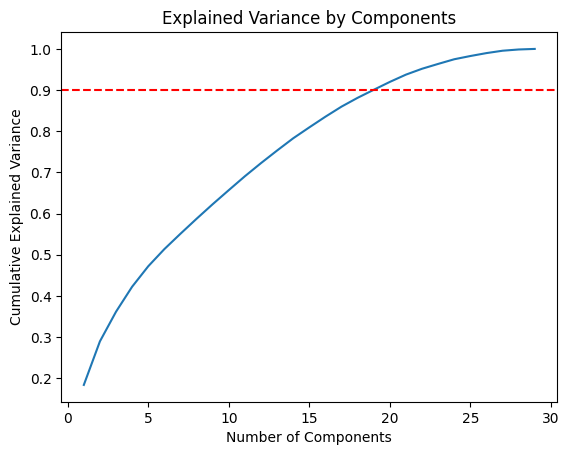

Number of components to retain 90% variance: 19


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Step 2: Apply PCA and fit the data
pca = PCA()  # No need to specify n_components for now
pca.fit(df[numeric_columns1])

# Step 3: Plot the cumulative explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Components')
plt.axhline(y=0.90, color='r', linestyle='--')  # Add a horizontal line at 90% variance
plt.show()

# Step 4: Choose the number of components
# For example, if you want to retain 90% variance:
n_components = np.argmax(cumulative_explained_variance >= 0.90) + 1
print(f"Number of components to retain 90% variance: {n_components}")


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

target_column = 'Target'
X = df.drop(columns=[target_column])
y = df[target_column]
scale = StandardScaler()
X_scaled = scale.fit_transform(X)

pca = PCA(n_components=16)
X_pca = pca.fit_transform(X_scaled)


X_pca_with_target = np.hstack((X_pca, y.values.reshape(-1, 1)))

print(f"Number of components used: {pca.n_components_}")
print("Explained variance ratio for each component:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))



Number of components used: 16
Explained variance ratio for each component: [0.18384497 0.105837   0.07203861 0.06070028 0.04962756 0.0416477
 0.0373126  0.0363924  0.03537358 0.03415872 0.03372604 0.03191229
 0.03060639 0.0297087  0.02652024 0.02589658]
Cumulative explained variance: [0.18384497 0.28968196 0.36172058 0.42242086 0.47204842 0.51369613
 0.55100873 0.58740113 0.62277471 0.65693343 0.69065947 0.72257175
 0.75317815 0.78288684 0.80940709 0.83530366]


In [ ]:
X_pca_with_target = pd.DataFrame(X_pca_with_target)

X_pca_with_target.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,-5.827224,-2.321041,0.457717,-0.544247,-0.562730,0.538169,0.904663,-0.403738,-1.354495,-0.361971,0.712506,-0.500250,0.675405,-0.633950,1.638262,-0.363449,0.0
1,0.251857,-1.556020,-2.483558,1.893691,1.137291,-1.163135,-0.054013,-0.171189,-0.184472,0.970729,-1.349105,-0.402088,0.080249,-0.231610,1.236955,-0.283546,1.0
2,-4.298687,-0.713548,1.754821,-1.934671,0.807047,-1.286067,-0.569447,0.682185,-0.625180,-0.973978,-0.373599,-1.330982,-0.103048,-0.338418,1.936502,0.021773,0.0
3,1.000506,-0.545911,0.578860,-1.243518,-0.981826,-0.484595,-1.114897,-1.378457,-0.215849,0.334618,-0.253246,-0.979450,-0.539667,1.273212,-0.729812,-1.096797,1.0
4,-0.123366,3.298992,1.122132,1.193173,-1.725413,1.394338,0.018766,-1.986787,0.010979,0.741781,0.648747,0.347286,0.358300,-1.908692,1.273457,-1.331638,1.0


In [ ]:
X_pca_with_target[16].value_counts()

,count
16,
1.0,2209
0.0,1421
2.0,794


In [ ]:
X_pca_with_target[16].unique()

array([0., 1., 2.])

In [ ]:
X_pca_with_target.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [ ]:
X = X_pca_with_target.drop(X_pca_with_target[16], axis=1).values
y = X_pca_with_target[16].values

In [ ]:
print(X)
print('\n')
print(y)

[[-0.54424708 -0.56272987  0.53816927 ...  1.63826222 -0.36344898
   0.        ]
 [ 1.89369138  1.13729131 -1.16313517 ...  1.2369552  -0.28354589
   1.        ]
 [-1.93467095  0.80704667 -1.28606748 ...  1.93650204  0.02177322
   0.        ]
 ...
 [ 2.25232641  0.46705181 -0.34977157 ...  0.27828463  0.45338181
   0.        ]
 [ 2.95127026  0.32700758 -0.59632265 ... -0.65576479  0.46053123
   1.        ]
 [ 2.18274582  1.49067347 -2.05319509 ...  1.02231991 -1.0000693
   1.        ]]


[0. 1. 0. ... 0. 1. 1.]


In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_res, y_res = ros.fit_resample(X, y)

In [ ]:
# Verify the new distribution of the target variable
target_distribution_resampled = pd.Series(y_res).value_counts()

# Print the new distribution
print(target_distribution_resampled)

0.0    2209
1.0    2209
2.0    2209
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.25, random_state=42)

In [ ]:
#Logistic regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification report:")
print(classification_report(y_test, y_pred))
print("\n")
print('Accuracy score:', accuracy_score(y_test, y_pred))

Classification report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       566
         1.0       1.00      1.00      1.00       553
         2.0       1.00      1.00      1.00       538

    accuracy                           1.00      1657
   macro avg       1.00      1.00      1.00      1657
weighted avg       1.00      1.00      1.00      1657



Accuracy score: 1.0


In [ ]:
from sklearn.svm import SVC

svm = SVC(random_state=42, probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)


print("SVM Accuracy:", accuracy_svm)
print("Classification Report:\n", report_svm)

SVM Accuracy: 0.996378998189499
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       566
         1.0       0.99      0.99      0.99       553
         2.0       1.00      1.00      1.00       538

    accuracy                           1.00      1657
   macro avg       1.00      1.00      1.00      1657
weighted avg       1.00      1.00      1.00      1657



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred)
report_knn = classification_report(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)
print("Classification Report:\n", report_knn)

KNN Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.87      0.90       566
         1.0       0.80      0.86      0.83       553
         2.0       0.90      0.92      0.91       538

    accuracy                           0.88      1657
   macro avg       0.89      0.88      0.88      1657
weighted avg       0.89      0.88      0.88      1657



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("Classification Report:\n", report_dt)


Decision Tree Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       566
         1.0       1.00      1.00      1.00       553
         2.0       1.00      1.00      1.00       538

    accuracy                           1.00      1657
   macro avg       1.00      1.00      1.00      1657
weighted avg       1.00      1.00      1.00      1657



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
report_gb = classification_report(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)
print("Classification Report:\n", report_gb)

Gradient Boosting Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       566
         1.0       1.00      1.00      1.00       553
         2.0       1.00      1.00      1.00       538

    accuracy                           1.00      1657
   macro avg       1.00      1.00      1.00      1657
weighted avg       1.00      1.00      1.00      1657



In [ ]:
from logging import LogRecord
from sklearn.ensemble import StackingClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

base_learners = [
    ('logreg', LogisticRegression(random_state=42)),
    ('svc', SVC(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

# Meta-model for stacking
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression())

# Ensemble method - Voting Classifier (Hard Voting)
voting_model = VotingClassifier(estimators=base_learners, voting='hard')

# Boosting model
boosting_model = GradientBoostingClassifier(random_state=42)

# Train and evaluate each model
models = {
    'Stacking Classifier': stacking_model,
    'Voting Classifier': voting_model,
    'Gradient Boosting': boosting_model
}

# Store results
results = {}
for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    results[model_name] = {'accuracy': accuracy}

results

{'Stacking Classifier': {'accuracy': 1.0},
 'Voting Classifier': {'accuracy': 1.0},
 'Gradient Boosting': {'accuracy': 1.0}}

In [ ]:
from sklearn.ensemble import StackingClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Base models for stacking
base_learners = [
    ('logreg', LogisticRegression(random_state=42)),
    ('svc', SVC(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

# Meta-model for stacking
stacking_model = StackingClassifier(estimators=base_learners, final_estimator=LogisticRegression())

# Ensemble method - Voting Classifier (Hard Voting)
voting_model = VotingClassifier(estimators=base_learners, voting='hard')

# Boosting model
boosting_model = GradientBoostingClassifier(random_state=42)

# Train and evaluate each model
models = {
    'Stacking Classifier': stacking_model,
    'Voting Classifier': voting_model,
    'Gradient Boosting': boosting_model
}

# Store results
results = {}
for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Make predictions on the training dataset
    y_pred_train = model.predict(X_train)

    # Evaluate the model on the training dataset
    accuracy_train = accuracy_score(y_train, y_pred_train)
    report_train = classification_report(y_train, y_pred_train)

    results[model_name] = {'accuracy_train': accuracy_train}

results


{'Stacking Classifier': {'accuracy_train': 1.0},
 'Voting Classifier': {'accuracy_train': 1.0},
 'Gradient Boosting': {'accuracy_train': 1.0}}

In [ ]:
from sklearn.model_selection import KFold, StratifiedKFold


# 1. K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_scores = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    kf_scores.append(accuracy_score(y_test, y_pred))

print("Average Accuracy (K-Fold):", np.mean(kf_scores))

# 2. Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_scores = []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    skf_scores.append(accuracy_score(y_test, y_pred))

print("Average Accuracy (Stratified K-Fold):", np.mean(skf_scores))

Average Accuracy (K-Fold): 1.0
Average Accuracy (Stratified K-Fold): 1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, GridSearchCV


# Create a KFold cross-validator (5 splits)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define models and hyperparameter grids for tuning
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {'C': [0.1, 1, 10], 'solver': ['liblinear', 'saga']}
    },
    'SVM': {
        'model': SVC(),
        'params': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(),
        'params': {'max_depth': [3, 5, 7], 'min_samples_split': [2, 5, 10]}
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    },
    'Random Forest': {
        'model': RandomForestClassifier(),
        'params': {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
    }
}

# Initialize a dictionary to store results
results = {}

# Perform cross-validation with hyperparameter tuning for each model
for model_name, model_info in models.items():
    model = model_info['model']
    param_grid = model_info['params']

    # GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring='accuracy')
    grid_search.fit(X, y)

    # Store the best model and its performance
    results[model_name] = {
        'Best Params': grid_search.best_params_,
        'Best Cross-Validation Accuracy': grid_search.best_score_
    }

# Print out the best parameters and cross-validation accuracy for each model
for model_name, result in results.items():
    print(f"{model_name}: Best Params = {result['Best Params']}, Best Cross-Validation Accuracy = {result['Best Cross-Validation Accuracy']:.4f}")
